# Business Understanding

## Contexto
A retenção de clientes representa um dos principais desafios enfrentados pelas instituições financeiras. A perda de clientes (Customer Churn) implica redução de receita, aumento dos custos de aquisição de novos clientes e impacto na lucratividade do negócio. Dessa forma, modelos preditivos capazes de identificar clientes com maior probabilidade de encerramento do relacionamento permitem direcionar campanhas de retenção de forma mais eficiente.

## Problema

Desenvolver um modelo preditivo capaz de estimar a probabilidade de um cliente abandonar o banco com base em suas características demográficas, financeiras e comportamentais.

## Objetivos

* compreender os fatores associados ao churn;
* desenvolver um modelo estatístico utilizando Regressão Logística;
* interpretar os coeficientes através de Odds Ratio;
* validar os pressupostos do modelo;
* avaliar seu desempenho através de métricas de classificação.

## Questões de Negócio

- Quais características estão mais associadas ao abandono de clientes?
- Idade influencia a probabilidade de churn?
- Clientes com maior saldo abandonam mais?
- O número de produtos contratados influencia a retenção?
- Clientes ativos possuem menor probabilidade de churn?
- É possível prever clientes com risco elevado de abandono utilizando regressão logística?

# Data Understanding

## Estratégia Analítica

O projeto será conduzido seguindo as etapas do processo de Ciência de Dados, iniciando pelo entendimento do problema, seguido da compreensão dos dados, análise exploratória, modelagem estatística e interpretação dos resultados.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings

from matplotlib import pyplot as plt

warnings.filterwarnings("ignore")
np.random.seed(42)

In [2]:
df = pd.read_csv('../data/raw/Churn_Modelling.csv', sep=',', na_values=[''], quotechar='"')
df.head().sort_values('CustomerId')

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


O conjunto de dados contém informações demográficas, financeiras e de relacionamento de clientes de uma instituição bancária. O objetivo é identificar os fatores associados ao abandono (Customer Churn), representado pela variável alvo Exited, indicando se o cliente permaneceu ou encerrou seu relacionamento com o banco.

CustomerId, RowNumber e Surname possuem caráter identificador e não representam atributos comportamentais do cliente, sendo removidos antes da modelagem.


In [3]:
for c in df.select_dtypes(include='object').columns:
    print(c)
    display(df[c].unique())

Surname


<StringArray>
[  'Hargrave',       'Hill',       'Onio',       'Boni',   'Mitchell',
        'Chu',   'Bartlett',     'Obinna',         'He',         'H?',
 ...
 'MacPherson',      'Parks',      'Edith',     'Lajoie',     'Torode',
    'Salinas',  'Cleveland',  'Kashiwagi',   'Aldridge',   'Burbidge']
Length: 2932, dtype: str

Geography


<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

Gender


<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Os valores Geography e Gender apresentam valores válidos para suas categorias. 
A variável Geography apresenta apenas três categorias (France, Germany e Spain), permitindo sua utilização em modelos preditivos por meio de codificação apropriada (por exemplo, One-Hot Encoding).


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [5]:
df.duplicated().sum()

np.int64(0)

Não foram identificados registros duplicados.

In [6]:
df.drop(columns=['CustomerId','RowNumber','Surname'],inplace=True)

In [7]:
df.tail()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [8]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [9]:
df.isna().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
target = 'Exited'
def mapear_tipo_variavel(coluna,dataframe):
    if dataframe[coluna].nunique() == 2:
        return 'Binária'
    elif pd.api.types.is_numeric_dtype(dataframe[coluna]):
        return 'Numérica'
    else:
        return 'Categórica'

df_info = pd.DataFrame({
    'Tipo': [mapear_tipo_variavel(col,df) for col in df.columns],
    'Tipo Original': df.dtypes,
    'Papel': ['Target' if col == target else 'Feature' for col in df.columns],
})
df_info.reset_index().rename(columns={'index':'Variável'}, inplace=True)
df_info


,Tipo,Tipo Original,Papel
CreditScore,Numérica,int64,Feature
Geography,Categórica,str,Feature
Gender,Binária,str,Feature
Age,Numérica,int64,Feature
Tenure,Numérica,int64,Feature
Balance,Numérica,float64,Feature
NumOfProducts,Numérica,int64,Feature
HasCrCard,Binária,int64,Feature
IsActiveMember,Binária,int64,Feature
EstimatedSalary,Numérica,float64,Feature


O dataset não apresenta valores ausentes, não sendo necessário tratamento nesta etapa.

In [11]:
df['Exited'].value_counts(normalize=True) *100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

array([[<Axes: title={'center': 'CreditScore'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Tenure'}>],
       [<Axes: title={'center': 'Balance'}>,
        <Axes: title={'center': 'NumOfProducts'}>,
        <Axes: title={'center': 'HasCrCard'}>],
       [<Axes: title={'center': 'IsActiveMember'}>,
        <Axes: title={'center': 'EstimatedSalary'}>,
        <Axes: title={'center': 'Exited'}>]], dtype=object)

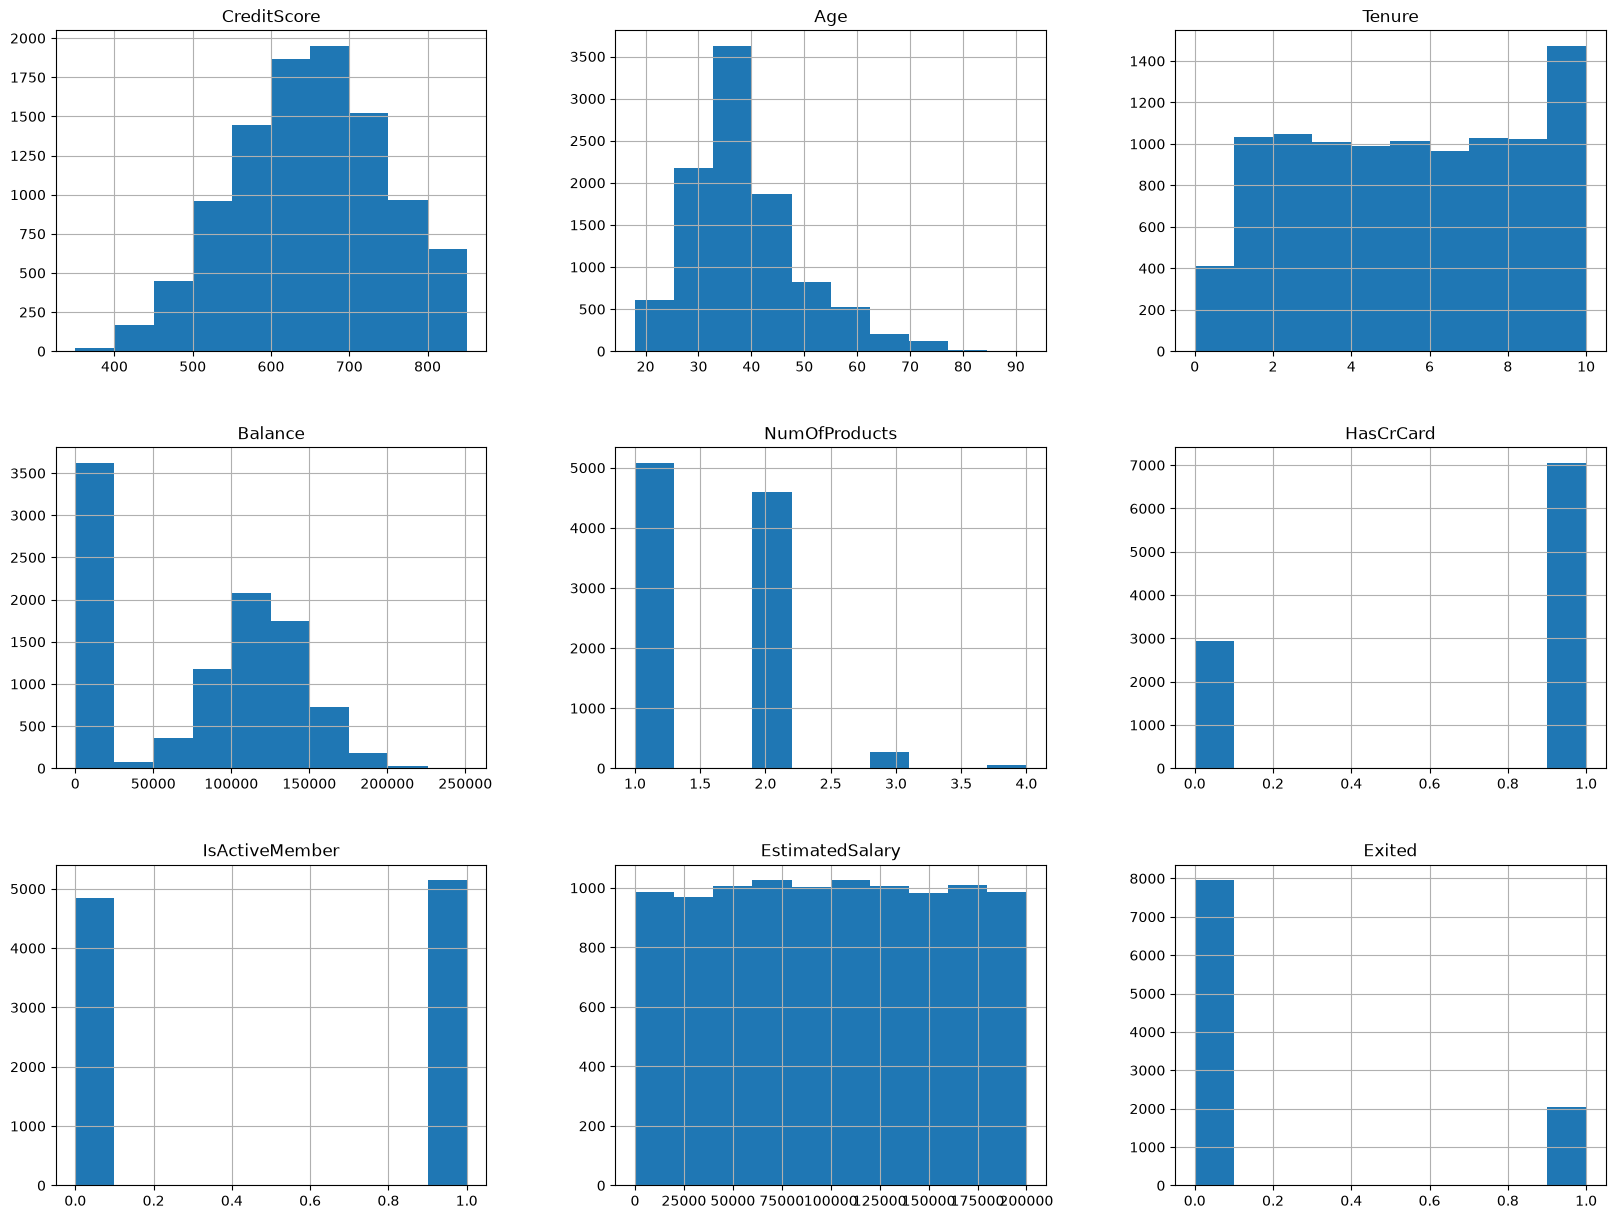

In [12]:
df.hist(figsize=(20,15))

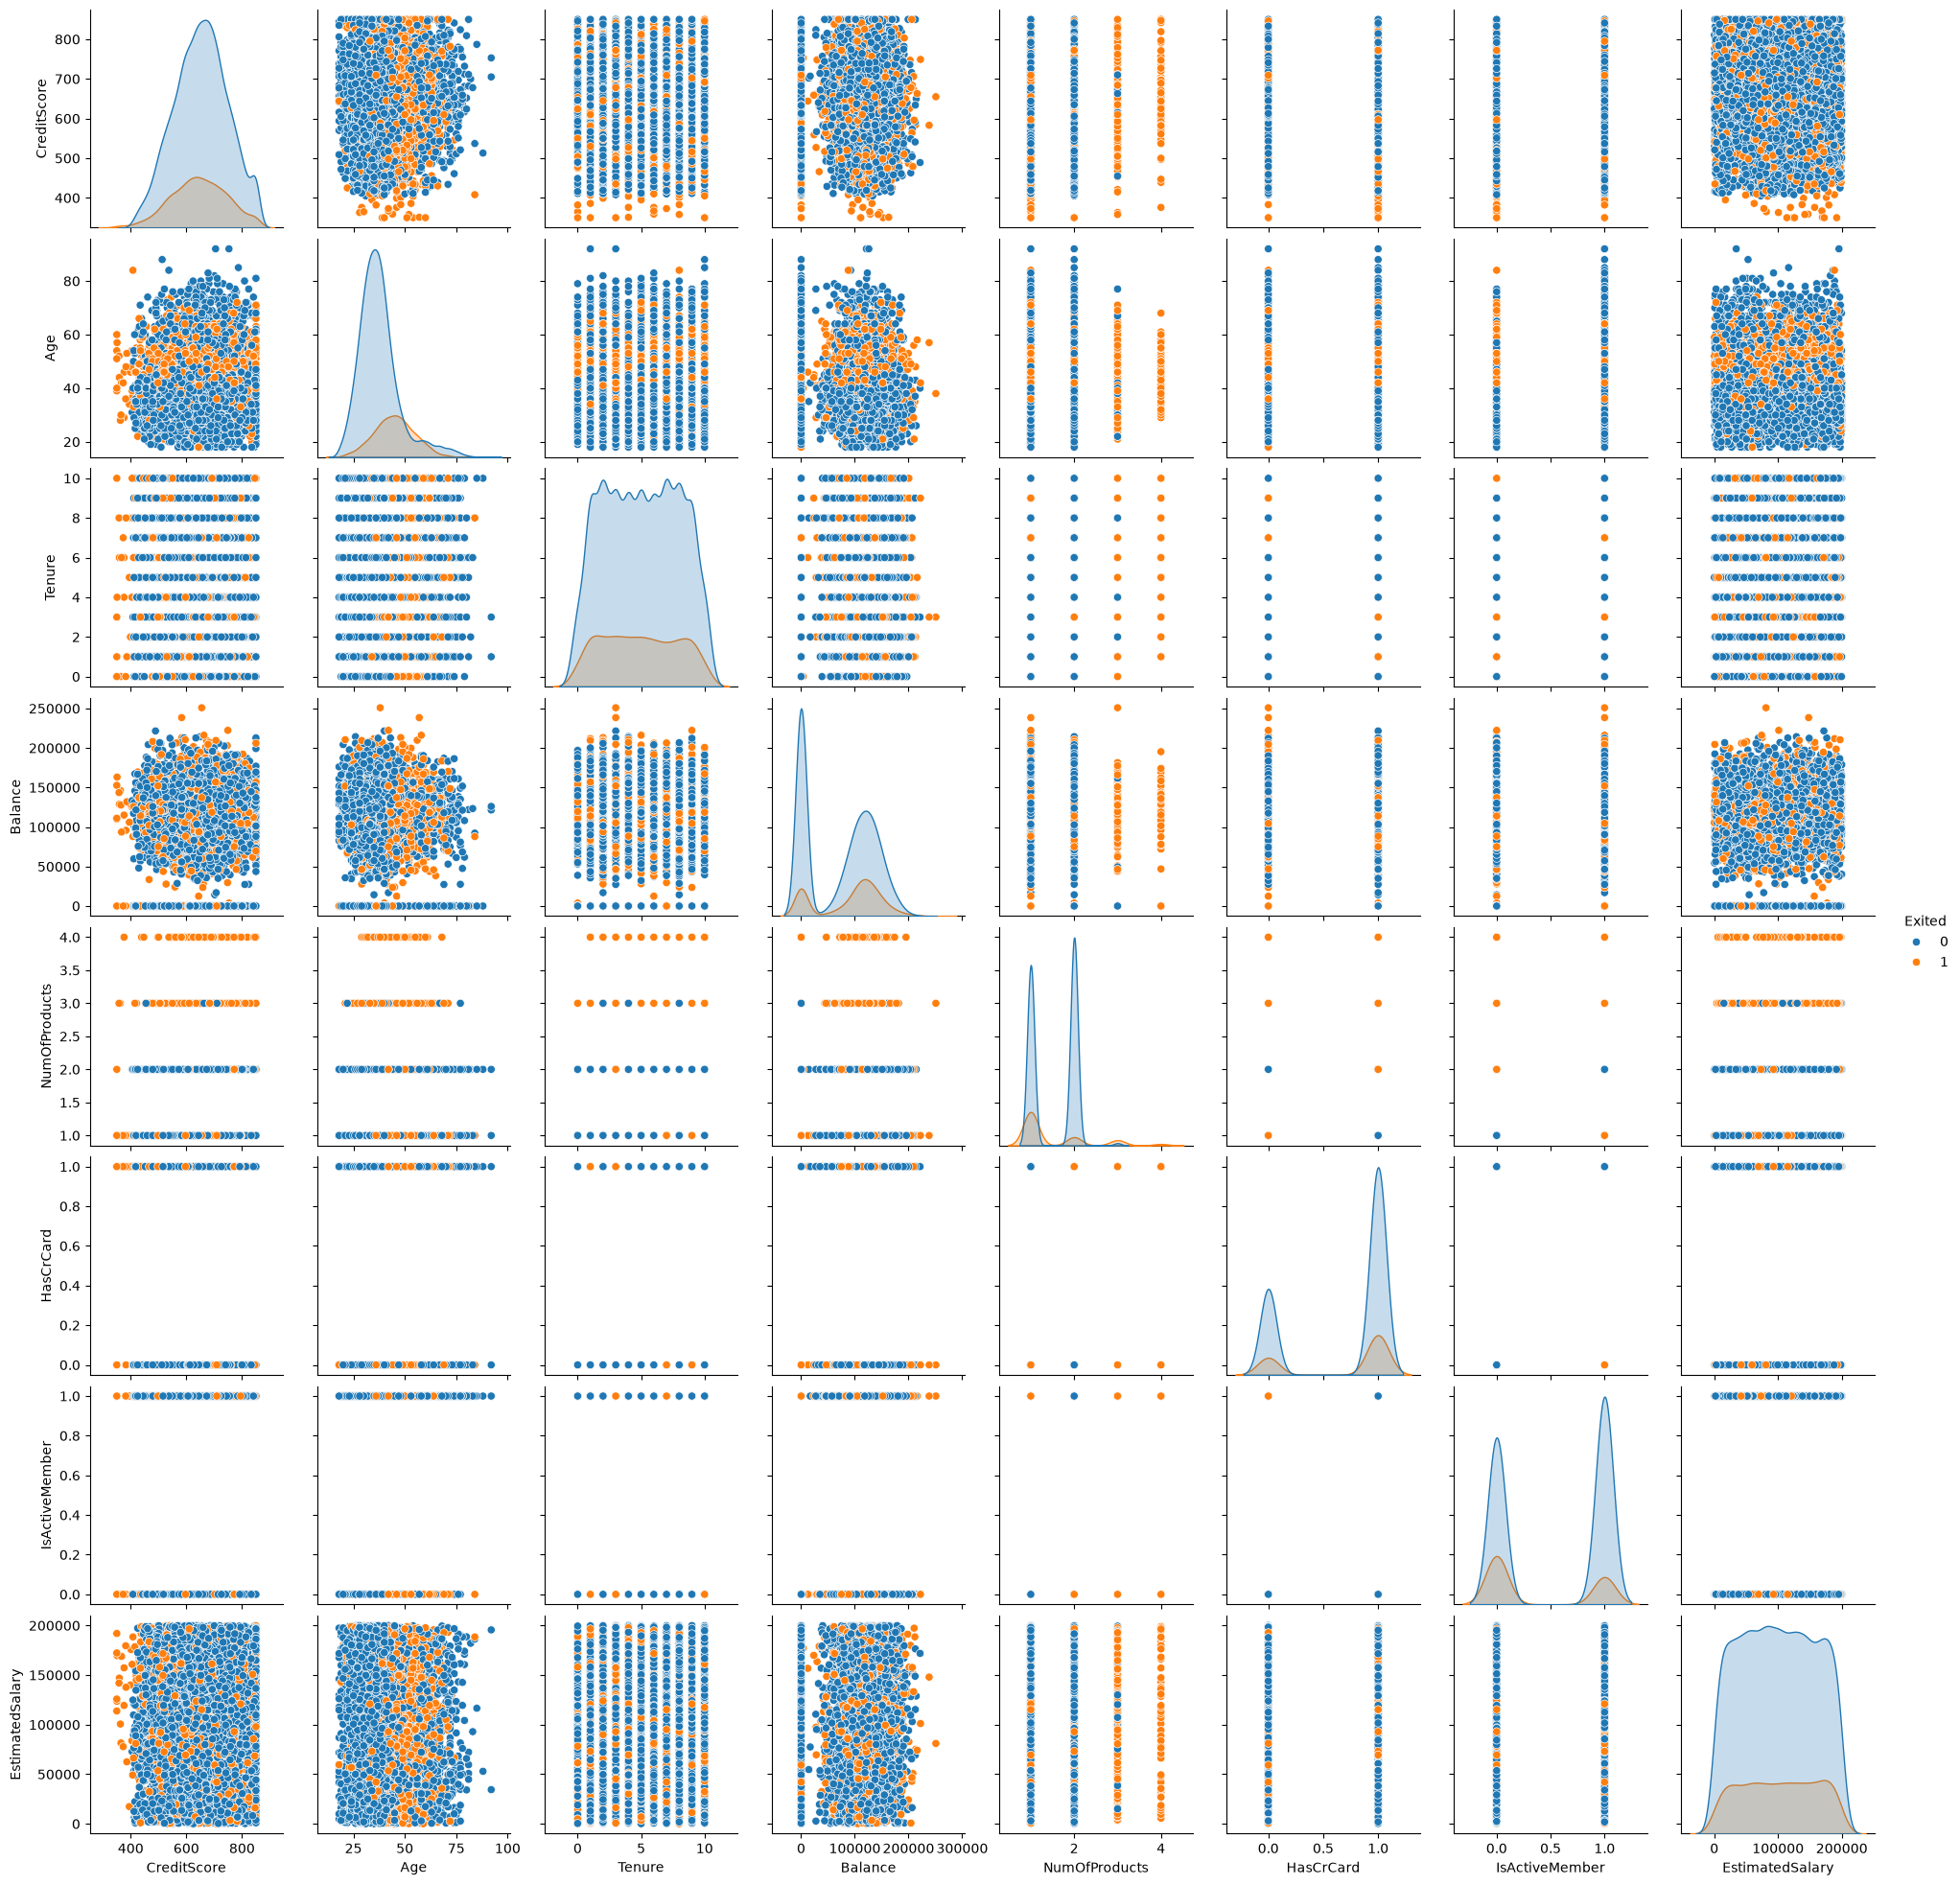

In [13]:
sns.pairplot(df,hue='Exited')

### Investigação - Valores extremos

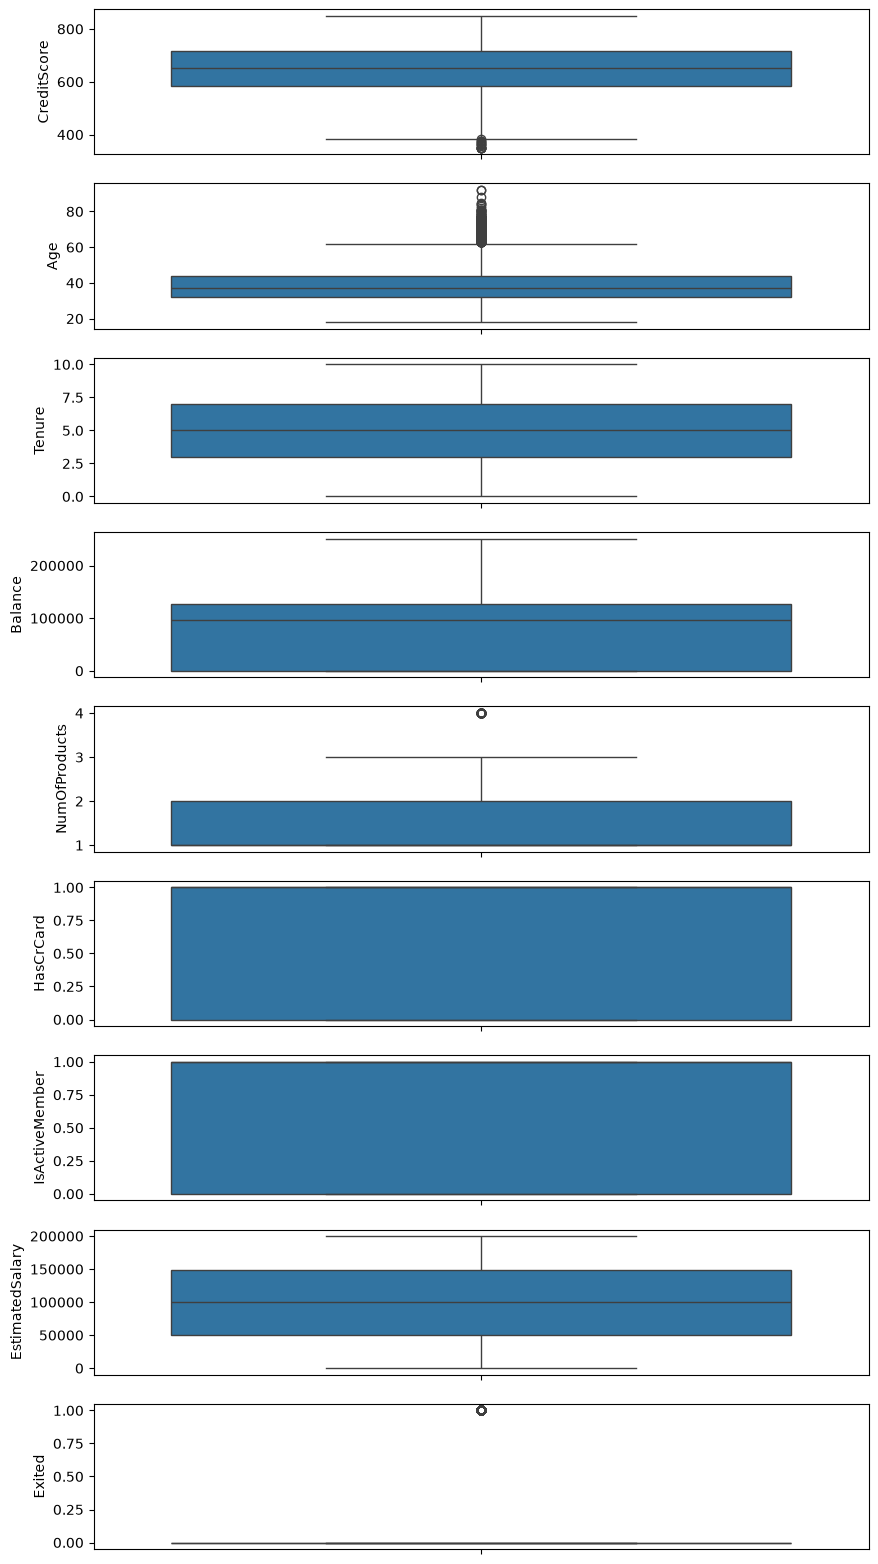

In [14]:
variaveis_numericas = df.select_dtypes(include='number')
fig, axes = plt.subplots(variaveis_numericas.shape[1], 1, figsize=(10,20))
for c, ax in zip(variaveis_numericas.columns, axes):
    sns.boxplot(df[c], ax=ax)

In [15]:
q1, q3  = variaveis_numericas.quantile(0.25), variaveis_numericas.quantile(0.75)
iqr = q3 - q1

limite_superior = (variaveis_numericas > q3 + 1.5 * iqr)
limite_inferior = variaveis_numericas < q1 - 1.5 * iqr
outiler_mascara = limite_inferior | limite_superior

In [16]:
variaveis_numericas = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'EstimatedSalary'
]
df[variaveis_numericas][outiler_mascara].count()

CreditScore         15
Age                359
Tenure               0
Balance              0
NumOfProducts       60
EstimatedSalary      0
dtype: int64

In [17]:
pd.crosstab(df['Exited'],pd.qcut(df['Age'],q=4),normalize='index')

Age,"(17.999, 32.0]","(32.0, 37.0]","(37.0, 44.0]","(44.0, 92.0]"
Exited,,,,
0,0.323622,0.257190,0.256436,0.162753
1,0.104566,0.122239,0.260677,0.512518


In [18]:
pd.crosstab(df['NumOfProducts'], df['Exited'])

Exited,0,1
NumOfProducts,,
1,3675,1409
2,4242,348
3,46,220
4,0,60


In [19]:
df[variaveis_numericas][outiler_mascara['CreditScore']].sort_values('CreditScore')

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
1838,350,39,0,109733.20,2,123602.11
1631,350,54,1,152677.48,1,191973.49
8723,350,51,10,0.00,1,125823.79
8762,350,60,3,0.00,1,113796.15
9624,350,40,0,111098.85,1,172321.21
2473,351,57,4,163146.46,1,169621.69
1962,358,52,8,143542.36,3,141959.11
1405,359,44,6,128747.69,1,146955.71
1193,363,28,6,146098.43,3,100615.14
2579,365,30,0,127760.07,1,81537.85


Embora a variável Age apresente 359 observações classificadas como outliers pelo método do IQR, verificou-se que essas observações concentram uma parcela expressiva dos clientes que realizaram churn. Dessa forma, os valores extremos representam um comportamento legítimo da população estudada e não erros de medição ou registro. Assim, optou-se por mantê-los na análise, uma vez que possuem elevado potencial informativo para o modelo preditivo.

A investigação dos outliers revelou padrões de negócio importantes, indicando que esses valores extremos representam segmentos específicos de clientes e não erros de coleta ou inconsistências do conjunto de dados.



## Conclusões da Investigação dos Valores Extremos

O conjunto possui 10.000 registros e 14 variáveis, sendo uma delas a variável alvo (Exited).
Não foram identificados valores ausentes nem registros duplicados.
As variáveis RowNumber, CustomerId e Surname possuem caráter identificador e serão desconsideradas na modelagem.

Observa-se um desbalanceamento moderado entre as classes (aproximadamente 80% de permanência e 20% de churn).
Aproximadamente 25% dos clientes apresentam saldo igual a zero, característica que merece investigação durante a análise exploratória.

O conjunto apresenta variáveis numéricas, categóricas e binárias, sendo adequado para aplicação de modelos de classificação como a Regressão Logística.

Com base no conhecimento do domínio, espera-se que idade, saldo, tempo de relacionamento, número de produtos e atividade do cliente apresentem associação com a probabilidade de churn.

O conjunto de dados apresenta alguns outliers, com mais expressividade na variável Age, que serão mantidos, pois pela investigação inicial tais outliers apresentam forte indicio de dados significativos de churn de clientes.


# Exploratory Data Analysis

A análise exploratória tem como objetivo investigar padrões, distribuições e possíveis relações entre as variáveis do conjunto de dados, buscando compreender fatores potencialmente associados ao churn e levantar hipóteses para a etapa de modelagem estatística.

## Investigação - Balance

<Axes: xlabel='Balance', ylabel='Count'>

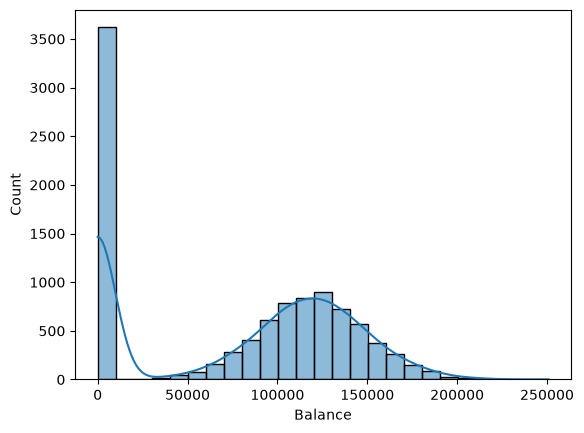

In [20]:
sns.histplot(df['Balance'],bins= 25, kde=True)

In [21]:
pd.crosstab(df[df['Balance']==0]['Balance'], df['Exited'], normalize=True) * 100

Exited,0,1
Balance,,
0.0,86.176389,13.823611


A variável Balance apresentou um comportamento distinto das demais variáveis numéricas. Uma grande concentração de clientes que possuem saldo igual a zero no primeiro quartil, formando um grupo separado da distribuição principal. Apesar dessa característica, esses clientes apresentaram taxa de churn inferior à média do conjunto de dados (13,8% contra aproximadamente 20,4%), sugerindo que saldo zero, isoladamente, não representa maior risco de abandono. Esse padrão indica a existência de diferentes perfis de clientes, hipótese que será explorada nas análises subsequentes.

In [22]:
pd.crosstab(df['Balance'][df['Balance'] == 0],pd.qcut(df['Age'],4), normalize=True) * 100

Age,"(17.999, 32.0]","(32.0, 37.0]","(37.0, 44.0]","(44.0, 92.0]"
Balance,,,,
0.0,29.582527,23.666022,25.546033,21.205419


A distribuição etária é relativamente muito homogênea, não parecendo influenciar churn.

In [23]:
pd.crosstab(df['Balance'][df['Balance'] == 0],df['Geography'], normalize=True) * 100

Geography,France,Spain
Balance,,
0.0,66.850981,33.149019


A alta concentração na França é um fenômeno exclusivo da França ou simplesmente existem muito mais clientes?

In [24]:
df['Geography'].value_counts(normalize=True)*100

Geography
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64

França representa aproximadamente 50% do conjunto de dados, tal observação merece uma investigação mais detalhada para entender o comportamento da variável Geography.

In [25]:
pd.crosstab(df['Balance'][df['Balance'] == 0],df['NumOfProducts'], normalize=True) * 100

NumOfProducts,1,2,3,4
Balance,,,,
0.0,25.020735,71.882776,2.709428,0.387061


Predominância do grupo de 2 produtos. Quem tem 2 produtos quantos têm saldo igual 0?

In [26]:
produtos_saldo0 = pd.crosstab(df['NumOfProducts'], df['Balance'] == 0, normalize='index') * 100
produtos_saldo0.rename(columns={False:'Saldo <> 0',True:'Saldo = 0'}, inplace=True)
produtos_saldo0.columns.name = ''
produtos_saldo0

,Saldo <> 0,Saldo = 0
NumOfProducts,,
1,82.199056,17.800944
2,43.355120,56.644880
3,63.157895,36.842105
4,76.666667,23.333333


In [27]:
pd.crosstab(df['Balance'] == 0,df['IsActiveMember']) * 100


IsActiveMember,0,1
Balance,,
False,310500,327800
True,174400,187300


In [28]:
pd.crosstab(df['Balance'][df['Balance'] == 0],df['IsActiveMember'], normalize=True) * 100

IsActiveMember,0,1
Balance,,
0.0,48.216754,51.783246


Quantos individuos de cada classe compoem o IsActiMember?

In [29]:
df['IsActiveMember'].value_counts(normalize=True)*100

IsActiveMember
1    51.51
0    48.49
Name: proportion, dtype: float64

In [30]:
atividade_cliente_saldo = pd.crosstab(index=df['IsActiveMember'].map({0: 'Inativo', 1: 'Ativo'}),
    columns=(df['Balance'] > 0).map({True: 'Saldo Positivo', False: 'Saldo Zero'}),
    rownames=['Status do Membro'],
    colnames=['Condição do Saldo'])
atividade_cliente_saldo.columns.name = ''

atividade_cliente_saldo['Total'] = atividade_cliente_saldo.sum(axis=1)
atividade_cliente_saldo['% Saldo Zero'] = atividade_cliente_saldo['Saldo Zero'] / atividade_cliente_saldo['Total'] * 100


atividade_cliente_saldo

,Saldo Positivo,Saldo Zero,Total,% Saldo Zero
Status do Membro,,,,
Ativo,3278,1873,5151,36.361871
Inativo,3105,1744,4849,35.966179


Verificou-se que o Balance apresentou um comportamento muito distintos do restante das outras variáveis, não foi evidenciado que a variável a idade possui influência na formação de grupos distintos do Balance, o mesmos verificou-se com o IsActiveMember.
Apesar de não encontrar evidencias fortes da influência do Geography no Balance, é necessária uma investigação mais detalhada em Geography.
Observou-se uma predominância de clientes que possuem dois produtos com o Balance igual a 0.

O comportamento do Balance sugere a hipótese que o mesmo é consequência do tipo de produto contratado.

## Investigação - Geography

Existe diferença de churn entre países?

In [31]:
pd.crosstab(df['Geography'], df['Exited'], normalize='index') * 100

Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


Por que os clientes da Alemanha abandonam mais?

In [32]:
df.groupby('Geography').mean(numeric_only=True)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
Geography,,,,,,,,,
France,649.668329,38.511767,5.004587,62092.636516,1.530913,0.706621,0.516753,99899.180814,0.161548
Germany,651.453567,39.771622,5.009964,119730.116134,1.519729,0.713830,0.497409,101113.435102,0.324432
Spain,651.333872,38.890997,5.032297,61818.147763,1.539362,0.694792,0.529673,99440.572281,0.166734


In [33]:
df.assign(
    HasBalance=df["Balance"].gt(0)
).groupby("Geography").agg(
    clientes=("Exited", "size"),
    churn_rate=("Exited", "mean"),
    pct_saldo_zero=("HasBalance", lambda x: (1 - x.mean()) * 100),
    saldo_medio_positivo=("Balance", lambda x: x[x > 0].mean()),
    saldo_mediano_positivo=("Balance", lambda x: x[x > 0].median())
)

,clientes,churn_rate,pct_saldo_zero,saldo_medio_positivo,saldo_mediano_positivo
Geography,,,,,
France,5014,0.161548,48.224970,119927.765597,120135.155
Germany,2509,0.324432,0.000000,119730.116134,119703.100
Spain,2477,0.166734,48.405329,119814.985923,119726.450


A análise exploratória mostrou que clientes da Alemanha apresentam taxa de churn aproximadamente duas vezes superior à observada na França e na Espanha. Essa diferença não parece ser explicada pelas médias de Credit Score, idade, tempo de relacionamento, número de produtos ou saldo médio entre clientes com saldo positivo, que se mostraram bastante semelhantes entre os países. Dessa forma, a variável Geography será mantida na modelagem para verificar se seu efeito permanece significativo após o controle das demais características dos clientes.

## Investigação - Tenure

O tempo de relacionamento influencia o churn?

In [34]:
df.groupby("Tenure")["Exited"].mean()*100

Tenure
0     23.002421
1     22.415459
2     19.179389
3     21.110010
4     20.525784
5     20.652174
6     20.268873
7     17.217899
8     19.219512
9     21.646341
10    20.612245
Name: Exited, dtype: float64

A variável será mantida para avaliação durante a modelagem, uma vez que a ausência de um padrão visual não implica necessariamente ausência de efeito quando analisada conjuntamente com as demais variáveis.

## Investigação - Age

A variável Age foi inicialmente investigada por apresentar a maior quantidade de outliers segundo o critério do IQR. Antes de qualquer remoção, buscou-se verificar se esses valores extremos representavam erros de medição ou características legítimas da população

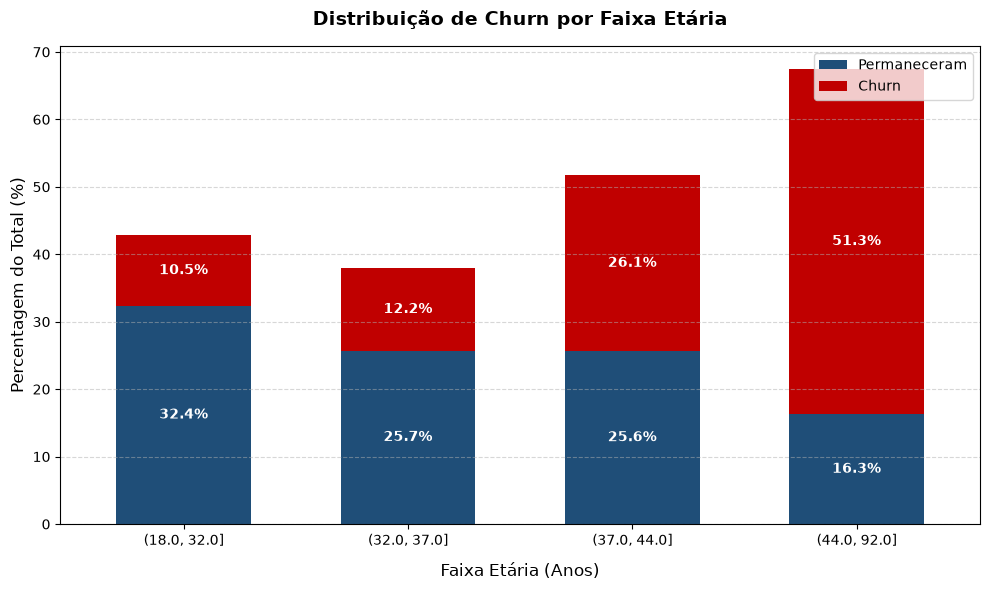

In [35]:
faixas_etarias = pd.crosstab(
    df['Exited'],
    pd.qcut(df['Age'], q=4),
    normalize='index'
) * 100

faixas_etarias_grafico = faixas_etarias.T

fig, ax = plt.subplots(figsize=(10, 6))
faixas_etarias_grafico.plot(kind='bar', stacked=True, color=['#1f4e78', '#c00000'], ax=ax, width=0.6)

ax.set_title('Distribuição de Churn por Faixa Etária', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Faixa Etária (Anos)', fontsize=12, labelpad=10)
ax.set_ylabel('Percentagem do Total (%)', fontsize=12)

rotulos_limpos = []
for intervalo in faixas_etarias_grafico.index:
    valores = str(intervalo).strip('()[]').split(', ')
    v_min = round(float(valores[0]), 1)
    v_max = round(float(valores[1]), 1)
    rotulos_limpos.append(f"({v_min}, {v_max}]")

ax.set_xticklabels(rotulos_limpos, rotation=0)
# -------------------------------------------------------------

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(['Permaneceram', 'Churn'], loc='upper right', frameon=True)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5:
        x, y = p.get_xy()
        ax.text(x + width/2, y + height/2, f'{height:.1f}%',
                color='white', weight='bold', ha='center', va='center', size=10)

plt.tight_layout()
plt.show()

Observa-se um aumento progressivo da taxa de churn conforme a idade aumenta. Enquanto clientes entre 18 e 32 anos apresentam aproximadamente 10% de churn, clientes acima de 44 anos apresentam taxa superior a 50%, indicando forte associação entre idade e abandono.

Apesar de classificados como outliers pelo método do IQR, os clientes mais idosos representam um segmento legítimo da população e apresentam comportamento significativamente diferente em relação ao churn. Dessa forma, optou-se por manter essas observações na base, uma vez que carregam informação relevante para a modelagem.

## Investigação - NumOfProducts

In [36]:
n_produtos_churn = pd.crosstab(
    df['NumOfProducts'],
    df['Exited'],
    normalize='index'
) * 100



produtos_churn = pd.crosstab(df['NumOfProducts'], df['Exited'])
produtos_churn.rename(columns={0:'Permanece', 1: 'Churn'}, inplace=True)
produtos_churn.columns.name = ''
produtos_churn["Total"] = produtos_churn['Permanece'] + produtos_churn['Churn']
produtos_churn["Taxa de Churn"] = n_produtos_churn[1]

produtos_churn = produtos_churn.style.format(
    lambda v: "0%" if v == 0.0 else f"{v:.2f}%".replace(".",','),
    subset=['Taxa de Churn']
)
produtos_churn



,Permanece,Churn,Total,Taxa de Churn
NumOfProducts,,,,
1,3675,1409,5084,"27,71%"
2,4242,348,4590,"7,58%"
3,46,220,266,"82,71%"
4,0,60,60,"100,00%"


Observou-se que a relação entre o número de produtos contratados e a ocorrência de churn não segue o comportamento inicialmente esperado. Clientes com dois produtos apresentaram a menor taxa de abandono (7,6%), enquanto clientes com três e quatro produtos exibiram taxas de churn de 82,7% e 100%, respectivamente. Esse resultado sugere que o número de produtos pode possuir uma relação não linear com a probabilidade de churn, hipótese que será investigada na etapa de modelagem.

## Investigação - CreditScore

In [37]:
qtde_churns_quartiles = pd.crosstab(pd.qcut(df['CreditScore'], q=4), df['Exited'])
creditscore_churns = pd.crosstab(pd.qcut(df['CreditScore'], q=4), df['Exited'], normalize='index') * 100
creditscore_churns["Permanece"] = qtde_churns_quartiles[0]
creditscore_churns["Churn"] = qtde_churns_quartiles[1]
creditscore_churns["Total"] = creditscore_churns["Permanece"] + creditscore_churns["Churn"]
creditscore_churns["Taxa de Churn"]  = creditscore_churns[1]
creditscore_churns.drop([0, 1],  inplace=True, axis=1)

creditscore_churns = creditscore_churns.style.format(
    lambda v: "0%" if v == 0.0 else f"{v:.2f}%".replace(".",','),
    subset=['Taxa de Churn']
)

creditscore_churns.columns.name = ''

creditscore_churns

,Permanece,Churn,Total,Taxa de Churn
CreditScore,,,,
"(349.999, 584.0]",1978,556,2534,"21,94%"
"(584.0, 652.0]",1975,526,2501,"21,03%"
"(652.0, 718.0]",2047,455,2502,"18,19%"
"(718.0, 850.0]",1963,500,2463,"20,30%"


A análise exploratória não evidenciou uma relação monotônica clara entre o Credit Score e a ocorrência de churn. As taxas de abandono permaneceram relativamente estáveis entre os quartis da variável, variando entre aproximadamente 18% e 22%. Isso sugere que, isoladamente, o Credit Score possui baixo poder discriminativo, embora sua contribuição em conjunto com outras variáveis deva ser avaliada durante a modelagem.

Hipóteses geradas na análise:

* Age pode apresentar forte associação com churn.
* NumOfProducts apresenta comportamento não linear.
* CreditScore, isoladamente, parece pouco discriminativo.
* O efeito do CreditScore pode depender de outras variáveis, especialmente Age.


# Principais Insights do EDA

* A idade apresentou forte associação com churn, especialmente entre clientes acima de 44 anos.
* Clientes com dois produtos apresentaram a menor taxa de churn observada.
* Clientes com três e quatro produtos apresentaram comportamento distinto, indicando possível relação não linear.
* Aproximadamente 36% dos clientes possuem saldo igual a zero, formando um grupo distinto da distribuição principal.
* Clientes com saldo zero apresentaram menor taxa de churn e estão fortemente associados a clientes com dois produtos.
* A Alemanha apresentou taxa de churn aproximadamente duas vezes superior à França e à Espanha.
* O CreditScore, analisado isoladamente, não apresentou relação monotônica evidente com o churn.

As análises exploratórias permitiram identificar padrões relevantes, formular hipóteses e compreender o comportamento das principais variáveis do conjunto de dados. Na próxima etapa será construída a regressão logística para avaliar quais dessas relações permanecem estatisticamente significativas quando consideradas simultaneamente.